# Introduction

This analysis's goal is answering the question: When is GeneralGoldenCat's server going to going to pass 1000 users.

First we are going to begin with installing required packages:

In [15]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


And now we can import required libraries:

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Data extraction

As a normal user, the analyser could not use advanced discord server tools. Also, Discord ToS forbids any form of script-based or bot-based message scrapping, so without day zero implemented bot that scans events and with no permissions, there is no way of automatically extracting data.

All the data that was gathered was gathered by the analyser, after reading through all the #welcome_new_members channel, where messages about user joining are being sent out both by default discord event system and bot. The data gathered and analysed is based on the bot server, where message format looks like this:

```
Carl bot (%timestamp): Hello, (%username), welcome to GeneralGoldenCat's Server. You are the (%currnumberofuser) st member to join.
```

The only two pieces of information required for analysis are `timestamp` and `currnumberofuser`. `timestamp` will help up with daily analysis, and `currnumberofuser` will help us with calculating members that joined (number rises up), members that left (there is no explicit leave message, but when users leave `currnumberofuser` is either stagnant or higher than before).

All the data was gathered to file user_net_growth.csv. File contains such data as:

- timestamp - Date of data aggregation
- user_gained - Users that joined the server that day
- user_lost - Users that left the server that day
- user_net_growth - Users that server gained that day (user_gained - user_lost)
- total_user - Total amount of user at the end of the day (after last join was concluded)

The data gathered does not perfectly show the user net dynamics, as there were some records missing and there is no clear timestamp for when and which user did leave. The users leaving are deduced based on the total number of users shown in the user joined message and the loss is aggregated to the day the timestamp has shown loss (by showing same total or less than before), so when there were days where no users left, the loss might not have been aggregated properly.

Now we import the data from the csv file:

In [17]:
user_data = pd.read_csv('user_net_growth.csv')  # Load user data from a CSV file

user_data.head()  # Display the first few rows of the dataset

,timestamp,user_gained,user_lost,user_net_growth,total_users
0,08-03-2026,2,0,2,2
1,09-03-2026,1,1,0,2
2,10-03-2026,0,0,0,2
3,11-03-2026,0,0,0,2
4,12-03-2026,0,0,0,2


# 3. Data exploration

In the table we have 1 date field, which is also a primary key for the data and 4 integer fields holding data connected to user base growth of the server.

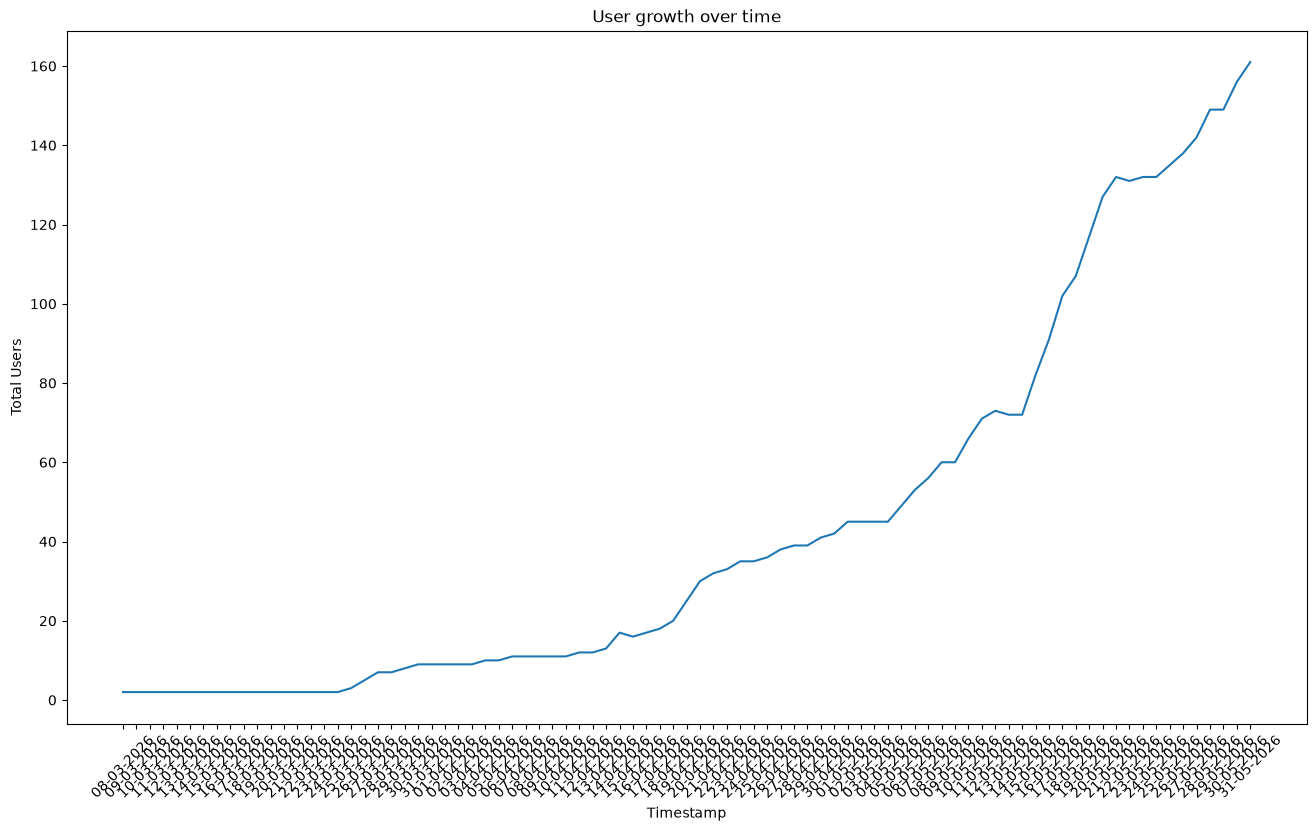

In [18]:
fig, ax = plt.subplots(figsize=(16, 9))  # Create a figure and axis for the plot
ax.plot(user_data['timestamp'], user_data['total_users'])  # Plot total users over time
ax.set_xlabel('Timestamp')  # Label the x-axis
ax.set_ylabel('Total Users')  # Label the y-axis
ax.set_title('User growth over time')  # Set the title of the plot
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()  # Show the plot of user growth over time